# 📞 Système de Prédiction du Churn Client — Telco
**Dataset** : Telco Customer Churn (IBM / Kaggle)  
**Objectif** : Prédire si un client va résilier son abonnement (Churn = Yes/No)  
**Pipeline** : Exploration → Prétraitement → Modèles → Évaluation → Interface

---

##  1. Import des librairies

In [1]:
import numpy as np
import pandas as pd

# Prétraitement
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Gestion du déséquilibre de classes
from imblearn.over_sampling import SMOTE

# Modèles supervisés
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Modèles non supervisés
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Évaluation
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Interface
import ipywidgets as widgets
from IPython.display import display, HTML

print(' Toutes les librairies importées')

 Toutes les librairies importées


---
##  2. Chargement et Exploration du Dataset

> **Source** : IBM Sample Dataset — Telco Customer Churn (Kaggle)  
> **Lien** : https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
> **Taille** : 7 043 clients, 21 variables  
> **Cible** : `Churn` = Yes (a résilié) / No (est resté)


In [2]:
# Chargement du dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f'Dataset synthétique généré : {df.shape[0]} lignes × {df.shape[1]} colonnes')

df.head()

Dataset synthétique généré : 7043 lignes × 21 colonnes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Informations générales
print(f' Dimensions : {df.shape}')
print(f'\n Distribution de la cible Churn :')
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100
for label in churn_counts.index:
    print(f'   {label:>3} : {churn_counts[label]:>5} clients ({churn_pct[label]:.1f}%)')
print(f'\n  Déséquilibre des classes : ratio {churn_pct["No"]/churn_pct["Yes"]:.1f}:1 (Non-churn vs Churn)')

 Dimensions : (7043, 21)

 Distribution de la cible Churn :
    No :  5174 clients (73.5%)
   Yes :  1869 clients (26.5%)

  Déséquilibre des classes : ratio 2.8:1 (Non-churn vs Churn)


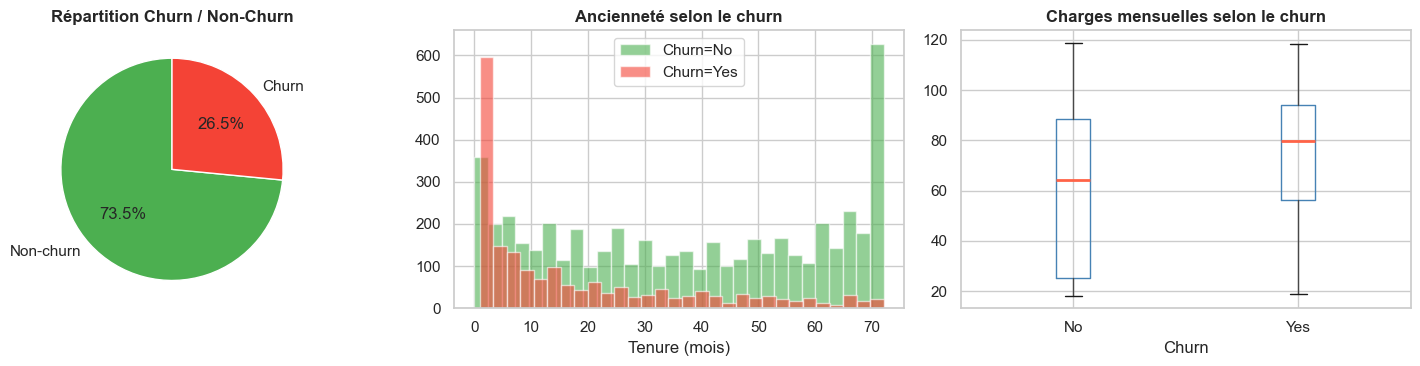

 Les clients churners ont une ancienneté plus faible et des charges plus élevées.


In [4]:
# Distribution de la cible + tenure par churn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Camembert churn
churn_counts.plot.pie(ax=axes[0], colors=['#4CAF50','#F44336'],
                      autopct='%1.1f%%', startangle=90, labels=['Non-churn','Churn'])
axes[0].set_title('Répartition Churn / Non-Churn', fontweight='bold')
axes[0].set_ylabel('')

# Tenure par churn
for label, color in [('No','#4CAF50'), ('Yes','#F44336')]:
    axes[1].hist(df[df['Churn']==label]['tenure'], bins=30,
                 alpha=0.6, color=color, label=f'Churn={label}')
axes[1].set_title('Ancienneté selon le churn', fontweight='bold')
axes[1].set_xlabel('Tenure (mois)')
axes[1].legend()

# MonthlyCharges par churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[2],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='tomato', linewidth=2))
axes[2].set_title('Charges mensuelles selon le churn', fontweight='bold')
axes[2].set_xlabel('Churn')
plt.suptitle('')

plt.tight_layout()
plt.savefig('exploration.png', bbox_inches='tight')
plt.show()
print(' Les clients churners ont une ancienneté plus faible et des charges plus élevées.')

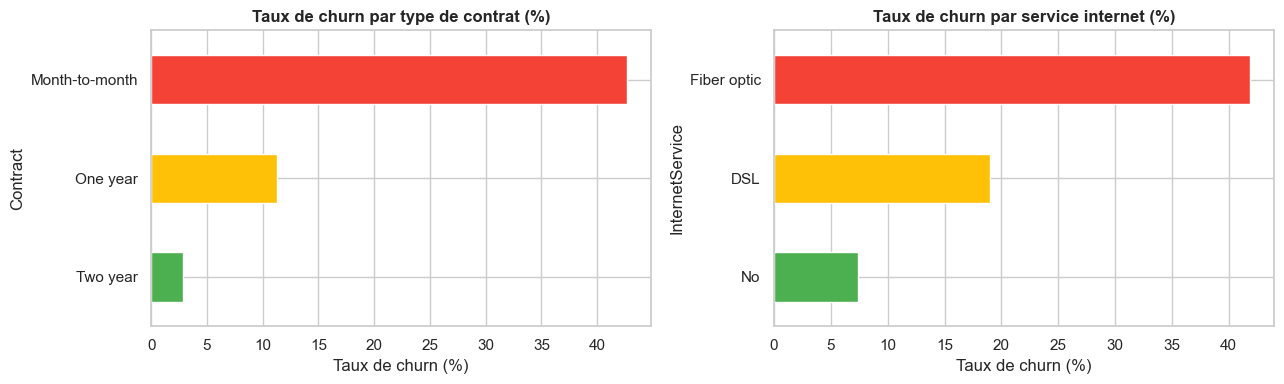

In [5]:
# Taux de churn par type de contrat
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
).sort_values(ascending=True)
contract_churn.plot.barh(ax=axes[0], color=['#4CAF50','#FFC107','#F44336'])
axes[0].set_title('Taux de churn par type de contrat (%)', fontweight='bold')
axes[0].set_xlabel('Taux de churn (%)')

internet_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
).sort_values(ascending=True)
internet_churn.plot.barh(ax=axes[1], color=['#4CAF50','#FFC107','#F44336'])
axes[1].set_title('Taux de churn par service internet (%)', fontweight='bold')
axes[1].set_xlabel('Taux de churn (%)')

plt.tight_layout()
plt.savefig('churn_by_category.png', bbox_inches='tight')
plt.show()

---
##  3. Prétraitement des Données

In [6]:
df_ml = df.copy()

# 1. Suppression de l'identifiant client (non prédictif)
df_ml.drop(columns=['customerID'], inplace=True)

# 2. Conversion de TotalCharges en numérique (peut contenir des espaces)
df_ml['TotalCharges'] = pd.to_numeric(df_ml['TotalCharges'], errors='coerce')

# 3. Traitement des valeurs manquantes
n_missing = df_ml.isnull().sum().sum()
df_ml['TotalCharges'].fillna(df_ml['TotalCharges'].median(), inplace=True)
print(f' Valeurs manquantes traitées : {n_missing}')

# 4. Encodage de la cible
df_ml['Churn'] = (df_ml['Churn'] == 'Yes').astype(int)
print(f' Cible encodée : No→0, Yes→1')

# 5. Encodage One-Hot des variables catégorielles
cat_cols = df_ml.select_dtypes(include='object').columns.tolist()
print(f' Variables catégorielles encodées ({len(cat_cols)}) : {cat_cols}')
df_ml = pd.get_dummies(df_ml, columns=cat_cols, drop_first=True)

print(f'\n Dimensions après encodage : {df_ml.shape}')
print(f'   {df_ml.shape[1]-1} features + 1 cible')

 Valeurs manquantes traitées : 11
 Cible encodée : No→0, Yes→1
 Variables catégorielles encodées (15) : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

 Dimensions après encodage : (7043, 31)
   30 features + 1 cible


C:\Users\HP\AppData\Local\Temp\ipykernel_25444\1579108680.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ml['TotalCharges'].fillna(df_ml['TotalCharges'].median(), inplace=True)


In [7]:
# Séparation features / cible
X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']
feature_names = X.columns.tolist()

# Split stratifié (préserve le ratio churn/non-churn dans train et test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'  Split stratifié 80/20 :')
print(f'   Train : {X_train.shape[0]} exemples | Churn rate : {y_train.mean()*100:.1f}%')
print(f'   Test  : {X_test.shape[0]}  exemples | Churn rate : {y_test.mean()*100:.1f}%')

  Split stratifié 80/20 :
   Train : 5634 exemples | Churn rate : 26.5%
   Test  : 1409  exemples | Churn rate : 26.5%


In [8]:
# Normalisation
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=feature_names)

# SMOTE — rééquilibrage des classes sur le train uniquement
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f'⚖️  Avant SMOTE : {y_train.value_counts().to_dict()}')
print(f'⚖️  Après SMOTE : {pd.Series(y_train_sm).value_counts().to_dict()}')
print(f'\n   Classes parfaitement équilibrées pour l\'entraînement !')

⚖️  Avant SMOTE : {0: 4139, 1: 1495}
⚖️  Après SMOTE : {0: 4139, 1: 4139}

   Classes parfaitement équilibrées pour l'entraînement !


---
## 4. Modélisation Supervisée

Trois modèles de **classification binaire** :
1. **Régression Logistique** — baseline interprétable
2. **Random Forest** — ensemble d'arbres robuste
3. **Gradient Boosting** — boosting séquentiel

Métriques adaptées au **déséquilibre de classes** : F1-score, AUC-ROC, matrice de confusion.

In [9]:
models = {
    'Régression Logistique' : LogisticRegression(max_iter=500, random_state=42),
    'Random Forest'         : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'     : GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = {}

for nom, modele in models.items():
    print(f' Entraînement : {nom}...', end=' ')
    modele.fit(X_train_sm, y_train_sm)
    y_pred      = modele.predict(X_test_scaled)
    y_prob      = modele.predict_proba(X_test_scaled)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    cm   = confusion_matrix(y_test, y_pred)

    results[nom] = {
        'modele'    : modele,
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
        'Accuracy'  : round(acc, 4),
        'F1-score'  : round(f1,  4),
        'AUC-ROC'   : round(auc, 4),
        'CM'        : cm
    }
    print(f' F1={f1:.3f} | AUC={auc:.3f} | Acc={acc:.3f}')

 Entraînement : Régression Logistique...  F1=0.618 | AUC=0.840 | Acc=0.738
 Entraînement : Random Forest...  F1=0.582 | AUC=0.824 | Acc=0.773
 Entraînement : Gradient Boosting...  F1=0.629 | AUC=0.840 | Acc=0.778


In [10]:
# Tableau comparatif
df_results = pd.DataFrame({
    nom: {k: v for k, v in info.items() if k not in ['modele','y_pred','y_prob','CM']}
    for nom, info in results.items()
}).T

print(' Comparaison des modèles :')
display(df_results.style
    .highlight_max(color='#c6efce')
    .format('{:.4f}')
)
best = df_results['F1-score'].idxmax()
print(f'\n Meilleur modèle (F1) : {best}')

 Comparaison des modèles :


,Accuracy,F1-score,AUC-ROC
Régression Logistique,0.7381,0.6176,0.8403
Random Forest,0.7729,0.5822,0.8240
Gradient Boosting,0.7779,0.6287,0.8396



 Meilleur modèle (F1) : Gradient Boosting


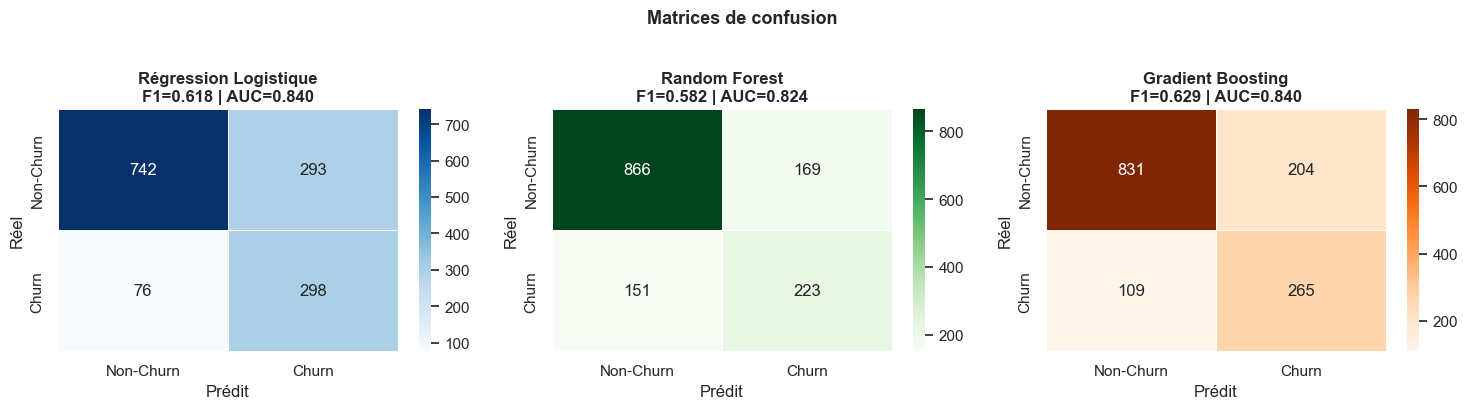

In [11]:
# Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_map = {'Régression Logistique': 'Blues', 'Random Forest': 'Greens', 'Gradient Boosting': 'Oranges'}

for ax, (nom, info) in zip(axes, results.items()):
    cm = info['CM']
    sns.heatmap(cm, annot=True, fmt='d', cmap=colors_map[nom], ax=ax,
                xticklabels=['Non-Churn','Churn'],
                yticklabels=['Non-Churn','Churn'],
                linewidths=0.5)
    ax.set_title(f'{nom}\nF1={info["F1-score"]:.3f} | AUC={info["AUC-ROC"]:.3f}', fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de confusion', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

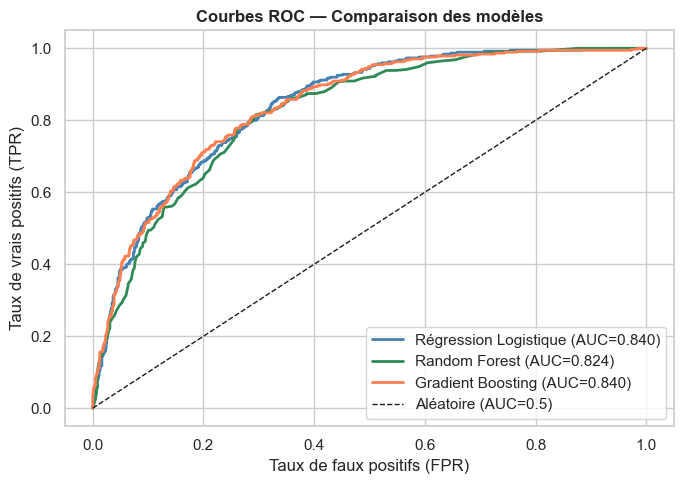

In [12]:
# Courbes ROC
fig, ax = plt.subplots(figsize=(7, 5))
colors = {'Régression Logistique': 'steelblue', 'Random Forest': 'seagreen', 'Gradient Boosting': 'coral'}

for nom, info in results.items():
    fpr, tpr, _ = roc_curve(y_test, info['y_prob'])
    ax.plot(fpr, tpr, color=colors[nom], linewidth=2,
            label=f'{nom} (AUC={info["AUC-ROC"]:.3f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Aléatoire (AUC=0.5)')
ax.set_xlabel('Taux de faux positifs (FPR)')
ax.set_ylabel('Taux de vrais positifs (TPR)')
ax.set_title('Courbes ROC — Comparaison des modèles', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

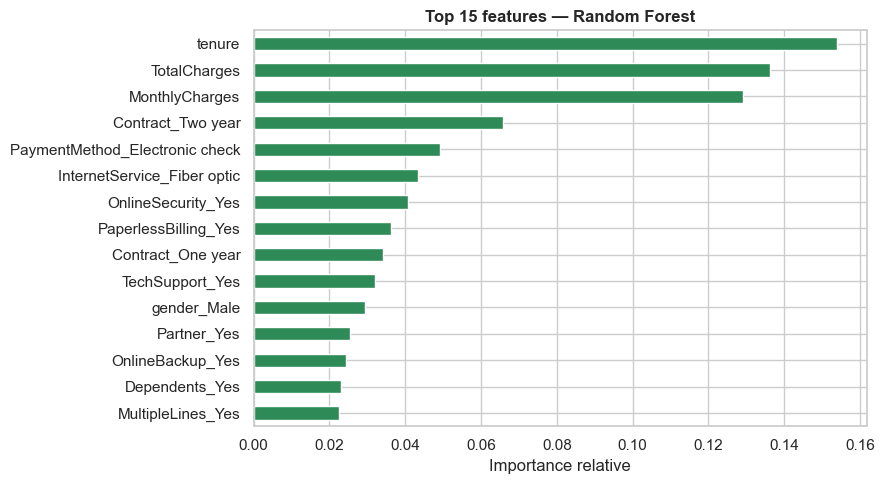


 Feature la plus prédictive : tenure


In [13]:
# Importance des features — Random Forest (top 15)
rf = results['Random Forest']['modele']
importances = pd.Series(rf.feature_importances_, index=feature_names)\
                .sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 5))
importances.plot.barh(ax=ax, color='seagreen', edgecolor='white')
ax.set_title('Top 15 features — Random Forest', fontweight='bold')
ax.set_xlabel('Importance relative')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print(f'\n Feature la plus prédictive : {importances.idxmax()}')

---
## 5. Apprentissage Non Supervisé (Bonus)
### 5a. Réduction de dimension — PCA

Variance expliquée : PC1=33.2% | PC2=12.0% | Total=45.2%


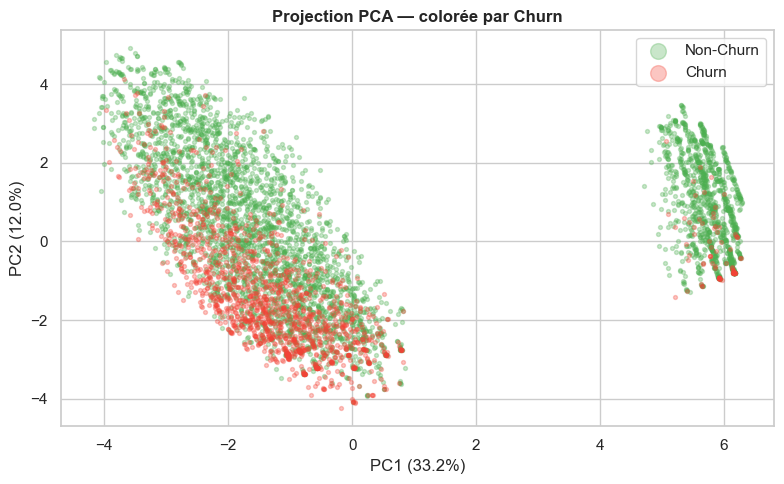

In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)
var = pca.explained_variance_ratio_

print(f'Variance expliquée : PC1={var[0]*100:.1f}% | PC2={var[1]*100:.1f}% | Total={sum(var)*100:.1f}%')

fig, ax = plt.subplots(figsize=(8, 5))
for label, color, name in [(0,'#4CAF50','Non-Churn'), (1,'#F44336','Churn')]:
    mask = (y_train == label).values
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, alpha=0.3, s=8, label=name)
ax.set_xlabel(f'PC1 ({var[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}%)')
ax.set_title('Projection PCA — colorée par Churn', fontweight='bold')
ax.legend(markerscale=4)
plt.tight_layout()
plt.savefig('pca_churn.png', bbox_inches='tight')
plt.show()

### 5 b. Segmentation clients — K-Means

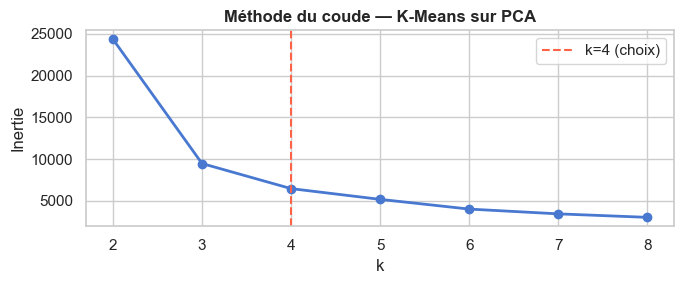

In [15]:
# Méthode du coude
inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(2, 9), inertias, 'bo-', linewidth=2, markersize=6)
ax.axvline(x=4, color='tomato', linestyle='--', label='k=4 (choix)')
ax.set_xlabel('k')
ax.set_ylabel('Inertie')
ax.set_title('Méthode du coude — K-Means sur PCA', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

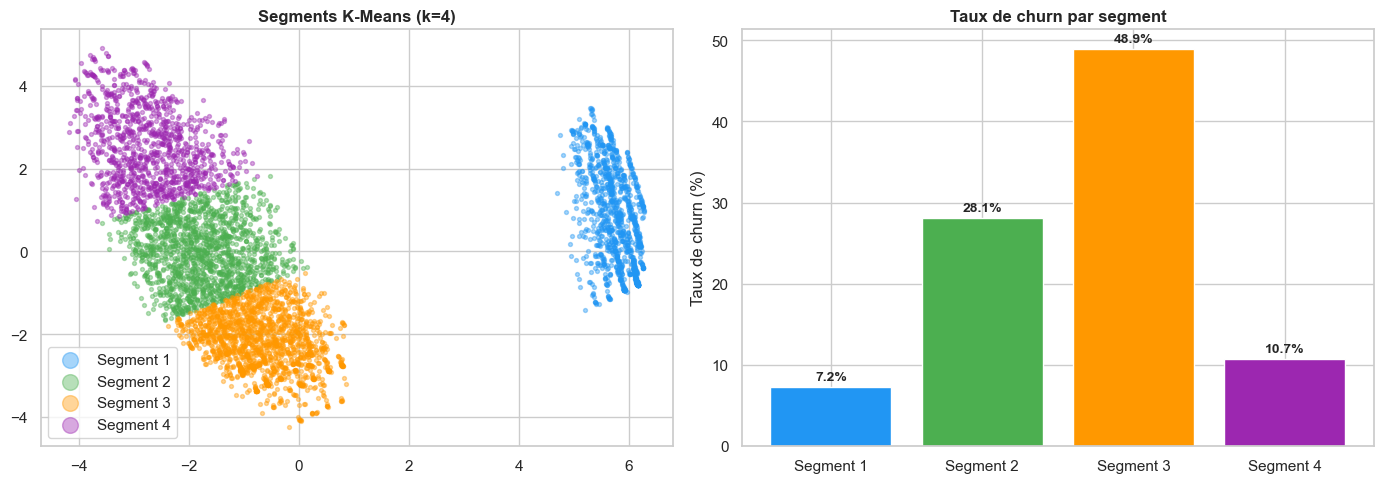


⚠️  Segment à risque maximal : Segment 3 (48.9% de churn)


In [16]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = ['#2196F3','#4CAF50','#FF9800','#9C27B0']

# Clusters
for i in range(4):
    mask = clusters == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=palette[i], alpha=0.4, s=8, label=f'Segment {i+1}')
axes[0].set_title('Segments K-Means (k=4)', fontweight='bold')
axes[0].legend(markerscale=4)

# Taux de churn par segment
seg_churn = pd.DataFrame({'cluster': clusters, 'churn': y_train.values})
churn_rate = seg_churn.groupby('cluster')['churn'].mean() * 100
bars = axes[1].bar(range(4), churn_rate, color=palette, edgecolor='white')
for bar, val in zip(bars, churn_rate):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_xticks(range(4))
axes[1].set_xticklabels([f'Segment {i+1}' for i in range(4)])
axes[1].set_ylabel('Taux de churn (%)')
axes[1].set_title('Taux de churn par segment', fontweight='bold')

plt.tight_layout()
plt.savefig('kmeans_churn.png', bbox_inches='tight')
plt.show()
print(f'\n⚠️  Segment à risque maximal : Segment {churn_rate.idxmax()+1} ({churn_rate.max():.1f}% de churn)')

---
##  6. Interface de Prédiction Interactive

> Renseignez le profil d'un client pour prédire sa probabilité de churn.  
> Modèle utilisé : **Gradient Boosting** (meilleur AUC-ROC).

In [17]:
best_model = results['Gradient Boosting']['modele']

style  = {'description_width': '230px'}
layout = widgets.Layout(width='500px')

# Widgets
w_tenure    = widgets.IntSlider(value=12, min=0, max=72, step=1,
                                description='📅 Ancienneté (mois) :',
                                style=style, layout=layout)
w_monthly   = widgets.FloatSlider(value=65.0, min=18.0, max=119.0, step=0.5,
                                  description='💰 Charges mensuelles ($) :',
                                  style=style, layout=layout)
w_contract  = widgets.Dropdown(
                  options=['Month-to-month','One year','Two year'],
                  description='📄 Type de contrat :', style=style, layout=layout)
w_internet  = widgets.Dropdown(
                  options=['DSL','Fiber optic','No'],
                  description='🌐 Service Internet :', style=style, layout=layout)
w_payment   = widgets.Dropdown(
                  options=['Electronic check','Mailed check',
                           'Bank transfer (automatic)','Credit card (automatic)'],
                  description='💳 Mode de paiement :', style=style, layout=layout)
w_paperless = widgets.Dropdown(options=['Yes','No'],
                  description='📧 Facturation en ligne :', style=style, layout=layout)
w_senior    = widgets.Dropdown(options=[('Non', 0), ('Oui', 1)],
                  description='👴 Senior citoyen :', style=style, layout=layout)
w_tech      = widgets.Dropdown(options=['Yes','No','No internet service'],
                  description='🔧 Support technique :', style=style, layout=layout)

btn    = widgets.Button(description='Prédire le churn', button_style='danger',
                        layout=widgets.Layout(width='200px', height='38px'))
output = widgets.Output()

def predict_churn(b):
    output.clear_output()

    # Construction du vecteur client avec les mêmes colonnes que X
    client_raw = {
        'SeniorCitizen' : w_senior.value,
        'tenure'        : w_tenure.value,
        'MonthlyCharges': w_monthly.value,
        'TotalCharges'  : w_tenure.value * w_monthly.value,
        'gender'        : 'Male',
        'Partner'       : 'No',
        'Dependents'    : 'No',
        'PhoneService'  : 'Yes',
        'MultipleLines' : 'No',
        'InternetService': w_internet.value,
        'OnlineSecurity' : 'No',
        'OnlineBackup'   : 'No',
        'DeviceProtection': 'No',
        'TechSupport'    : w_tech.value,
        'StreamingTV'    : 'No',
        'StreamingMovies': 'No',
        'Contract'       : w_contract.value,
        'PaperlessBilling': w_paperless.value,
        'PaymentMethod'  : w_payment.value,
    }
    client_df = pd.DataFrame([client_raw])
    cat_c = client_df.select_dtypes(include='object').columns.tolist()
    client_enc = pd.get_dummies(client_df, columns=cat_c, drop_first=True)

    # Alignement avec les colonnes d'entraînement
    for col in feature_names:
        if col not in client_enc.columns:
            client_enc[col] = 0
    client_enc = client_enc[feature_names]

    client_scaled = pd.DataFrame(scaler.transform(client_enc), columns=feature_names)
    prob_churn    = best_model.predict_proba(client_scaled)[0][1]
    pred_churn    = prob_churn > 0.5

    if prob_churn >= 0.7:
        couleur, icone, niveau = '#c0392b', '🔴', 'RISQUE ÉLEVÉ'
    elif prob_churn >= 0.4:
        couleur, icone, niveau = '#e67e22', '🟠', 'RISQUE MODÉRÉ'
    else:
        couleur, icone, niveau = '#27ae60', '🟢', 'FAIBLE RISQUE'

    with output:
        display(HTML(f"""
        <div style='background:#fafafa; border:2px solid {couleur}; border-radius:12px;
                    padding:18px 24px; margin-top:14px; max-width:480px;'>
          <h3 style='margin:0 0 10px; color:{couleur};'>{icone} Prédiction de Churn — {niveau}</h3>
          <p style='font-size:2em; font-weight:bold; color:{couleur}; margin:0;'>
            {prob_churn*100:.1f}% de probabilité de churn
          </p>
          <p style='color:#555; margin:8px 0;'>
            Décision : <b>{'Churn probable' if pred_churn else 'Client fidèle'}</b>
          </p>
          <hr style='margin:10px 0; border-color:#ddd;'>
          <div style='background:#eee; border-radius:6px; height:14px; overflow:hidden;'>
            <div style='background:{couleur}; width:{prob_churn*100:.1f}%; height:100%;'></div>
          </div>
          <small style='color:#888; margin-top:6px; display:block;'>
            Modèle : Gradient Boosting — AUC={results['Gradient Boosting']['AUC-ROC']:.3f}
          </small>
        </div>
        """))

btn.on_click(predict_churn)

display(HTML('<h3 style="margin-bottom:8px">📞 Profil du Client</h3>'))
display(widgets.VBox([
    w_tenure, w_monthly, w_contract, w_internet,
    w_payment, w_paperless, w_senior, w_tech,
    widgets.HBox([btn]),
    output
]))